In [6]:

import importlib
import librosa 
import numpy as np 
import pandas as pd
import scipy as sci
import matplotlib.pyplot as plt
import noisereduce as nr
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
import re
import parselmouth as pm
from sklearn.metrics import root_mean_squared_error
import functions
importlib.reload(functions);




In [7]:
dataset = pd.read_csv('development.csv')
dataset

,Id,sampling_rate,age,gender,ethnicity,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,num_words,num_characters,num_pauses,silence_duration,path
0,0,22050,24.0,female,arabic,1821.69060,3999.7170,145.43066,0.013795,0.082725,0.002254,0.210093,3112.257251,[151.99908088],-123.999726,69,281,39,23.846893,audios_development/1.wav
1,1,22050,22.5,female,hungarian,1297.81870,3998.8590,145.37268,0.025349,0.096242,0.007819,0.078849,1688.016389,[129.19921875],-86.928478,69,281,21,19.388662,audios_development/2.wav
2,2,22050,22.0,female,portuguese,1332.85240,3998.8025,145.42395,0.019067,0.119456,0.002974,0.105365,2576.901706,[117.45383523],-98.450670,69,281,1,21.640998,audios_development/3.wav
3,3,22050,22.0,female,english,1430.34990,3998.4510,147.98083,0.017004,0.102389,0.022371,0.173701,3269.751413,[117.45383523],-56.459762,69,281,9,19.644127,audios_development/4.wav
4,4,22050,22.0,male,dutch,1688.72340,3998.6113,145.44772,0.028027,0.124831,0.005369,0.107279,1930.897375,[112.34714674],-80.349204,69,281,11,18.041905,audios_development/5.wav
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2928,2928,22050,24.0,male,english,1641.14930,3999.1616,145.39359,0.023647,0.115361,0.001879,0.111799,2188.853478,[184.5703125],-100.921055,69,281,11,17.461406,audios_development/2929.wav
2929,2929,22050,15.0,female,igbo,1089.60050,3984.6550,145.58409,0.015317,0.126740,0.000339,0.070508,2712.362323,[83.35433468],6.757283,0,0,1,1.509206,audios_development/2930.wav
2930,2930,22050,17.0,female,igbo,994.46484,3989.1785,148.97475,0.009677,0.103535,0.001464,0.058442,2248.698477,[89.10290948],-53.913449,1,9,1,1.645034,audios_development/2931.wav
2931,2931,22050,18.0,male,arabic,1600.00820,3999.7559,145.36101,0.019571,0.100946,0.004451,0.115139,1834.596924,[143.5546875],-96.143090,69,281,19,16.346848,audios_development/2932.wav


In [8]:
dataset.info()
#No null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2933 entries, 0 to 2932
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Id                      2933 non-null   int64  
 1   sampling_rate           2933 non-null   int64  
 2   age                     2933 non-null   float64
 3   gender                  2933 non-null   object 
 4   ethnicity               2933 non-null   object 
 5   mean_pitch              2933 non-null   float64
 6   max_pitch               2933 non-null   float64
 7   min_pitch               2933 non-null   float64
 8   jitter                  2933 non-null   float64
 9   shimmer                 2933 non-null   float64
 10  energy                  2933 non-null   float64
 11  zcr_mean                2933 non-null   float64
 12  spectral_centroid_mean  2933 non-null   float64
 13  tempo                   2933 non-null   object 
 14  hnr                     2933 non-null   

In [9]:
pd.unique(dataset['sampling_rate'])


array([22050])

In [10]:
sampling_rate = dataset['sampling_rate'][0]
dev_paths  = dataset['path']


In [11]:
pd.unique(dataset['ethnicity'])

array(['arabic', 'hungarian', 'portuguese', 'english', 'dutch', 'italian',
       'french', 'igbo', 'hebrew', 'farsi', 'german', 'nama', 'belarusan',
       'urhobo', 'polish', 'croatian', 'kikuyu', 'icelandic', 'bengali',
       'maltese', 'finnish', 'armenian', 'hindi', 'bosnian', 'miskito',
       'azerbaijani', 'kiswahili', 'mongolian', 'russian', 'malay',
       'bulgarian', 'gan', 'cantonese', 'punjabi', 'nigerian', 'mandarin',
       'oriya', 'igala', 'japanese', 'ga', 'ibibio', 'korean', 'amharic',
       'gujarati', 'norwegian', 'kurdish', 'congolese', 'marathi', 'ijaw',
       'nepali', 'indonesian', 'yoruba', 'bari', 'kanuri', 'pashto',
       'romanian', 'albanian', 'georgian', 'baga', 'macedonian', 'danish',
       'khmer', 'catalan', 'papiamentu', 'naxi', 'czech', 'mizo', 'irish',
       'agni', 'hausa', 'estonian', 'ika', 'bafang', 'quechua',
       'lithuanian', 'afemai', 'ikwerre', 'luxembourgeois', 'moore',
       'kabyle', 'fijian', 'greek', 'mankanya', "sa'a", 'bai'

In [12]:
pd.unique(dataset['ethnicity']).shape

(165,)

In [13]:
#count how many people are in each ethnicity
cout = np.zeros(pd.unique(dataset['ethnicity']).shape[0])
etn = pd.unique(dataset['ethnicity'])
for i in range(len(etn)):
    cout[i] = dataset[dataset['ethnicity'] == etn[i]].shape[0]
sorted_etn = pd.DataFrame(cout, index=etn, columns=['count']).sort_values(by='count', ascending=False)
sorted_etn['ratio'] = sorted_etn['count']/sorted_etn['count'].sum()
sorted_etn['csum'] = sorted_etn['ratio'].cumsum()

In [14]:
sorted_etn  

,count,ratio,csum
igbo,1081.0,0.368565,0.368565
english,579.0,0.197409,0.565973
arabic,102.0,0.034777,0.600750
mandarin,65.0,0.022162,0.622912
french,63.0,0.021480,0.644391
...,...,...,...
hakka,1.0,0.000341,0.998636
malagasy,1.0,0.000341,0.998977
lingala,1.0,0.000341,0.999318
fang,1.0,0.000341,0.999659


In [15]:
#how many etnicity group 90% of the data
for i in np.arange(0.3,1,0.1):
    print(f'For the {i*100}% of the data we need {sorted_etn[sorted_etn["csum"]<i].shape[0]} vals') 



For the 30.0% of the data we need 0 vals
For the 40.0% of the data we need 1 vals
For the 50.0% of the data we need 1 vals
For the 60.00000000000001% of the data we need 2 vals
For the 70.00000000000001% of the data we need 8 vals
For the 80.00000000000003% of the data we need 18 vals
For the 90.00000000000001% of the data we need 40 vals


<BarContainer object of 10 artists>

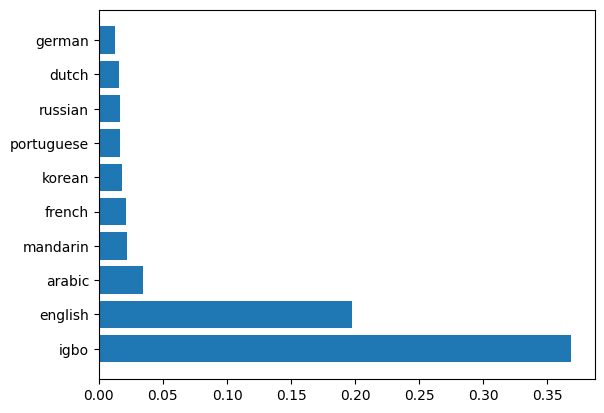

In [16]:
#with the first three ethnicity groups we have 60% of the data
plt.barh(sorted_etn.index[:10], sorted_etn['ratio'][:10])  

In [17]:
#it may be worth try using only the firt two or thre  

In [18]:
#I will make a function to one hot encode only the first n ethnicity groups
def one_hot_ethnicity(dataset:pd.DataFrame, n, etn:pd.DataFrame):
    """function that takes in input the dataset, the number of ethnicity groups to one hot encode and a dataset of the sorted
    frequency of the ethnicity groups and returns the dataset with the one hot encoding and removes the original row ethnicity

    Args:
        dataset (pd.DataFrame): Dataset to be one hot encoded
        n (_type_): How many dimentions to one hot encode
        etn (pd.DataFrame): Dataset with the frequency of the ethnicity groups

    Returns:
        dataset (pd.DataFrame): Dataset with the one hot encoding and without the column ethnicity
    """
    
    dummies = pd.get_dummies(dataset['ethnicity'])
    # print(dummies[etn.index[:n].values])
    dataset = pd.concat([dataset, dummies[etn.index[:n].values]], axis=1)
    dataset.drop(columns =['ethnicity'], inplace=True)  
    # display(dataset)
    return dataset

In [19]:
def drop_cols(dataset:pd.DataFrame, cols)->pd.DataFrame: 
    return dataset.drop(columns=cols) 

In [20]:
def extract_float_from_brackets(s: str) -> float:
    
    pattern = r"\[(\d+\.\d+)\]" #pattern to find a floar number between brackets
    match = re.search(pattern, s)
    return float(match.group(1)) 
        
    
def make_tempo_float(dataset:pd.DataFrame)->pd.DataFrame:
    dataset['tempo'] = dataset['tempo'].apply(lambda x: extract_float_from_brackets(x))
    return dataset

In [21]:
def encode_gendedr(dataset:pd.DataFrame)->pd.DataFrame:
    #i will encode the male as true and the female as false
    dataset['gender'] = dataset['gender'].apply(lambda x: True if x =='male' else False)
    return dataset

In [22]:
sorted_etn.iloc[1]

count    579.000000
ratio      0.197409
csum       0.565973
Name: english, dtype: float64

In [23]:
#I will discard the gender colum for now and choose leater the best way to encode it
y = dataset['age']


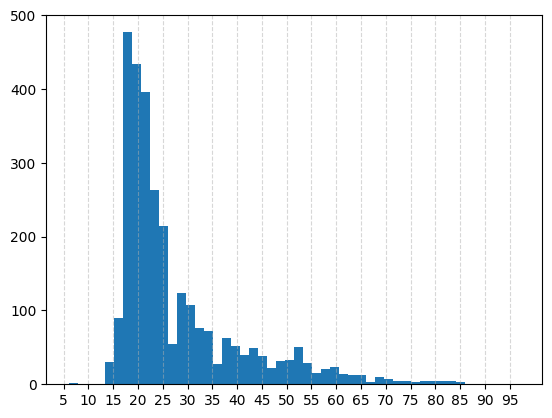

In [24]:
plt.xticks(np.arange(0,100,5))
plt.grid(axis='x', linestyle='--',alpha=0.5)
plt.hist(y, bins=50);

In [25]:
#distribuzione delle eta ho molti dati tra i 20 e i 34 poch dopo  

In [26]:
dataset = encode_gendedr(dataset)

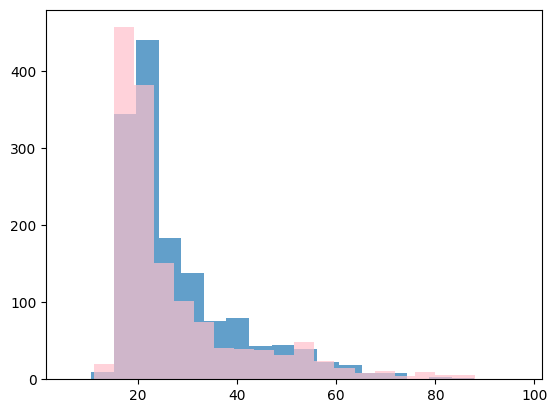

In [27]:
#i want to see the distribution of the geneder and the age
males = dataset[dataset['gender']]
females = dataset[dataset['gender'] == False]
plt.hist(males['age'],bins=20,alpha=0.7)
plt.hist(females['age'],bins=20,alpha=0.7, color='pink');    


Male and famale have the same distribution 

In [28]:
#aggiungo la lunghezza degli audio come feature
duration = functions.extract_audio_duration(dev_paths,filtered= False)

In [29]:
sorted_etn[1:]

,count,ratio,csum
english,579.0,0.197409,0.565973
arabic,102.0,0.034777,0.600750
mandarin,65.0,0.022162,0.622912
french,63.0,0.021480,0.644391
korean,52.0,0.017729,0.662121
...,...,...,...
hakka,1.0,0.000341,0.998636
malagasy,1.0,0.000341,0.998977
lingala,1.0,0.000341,0.999318
fang,1.0,0.000341,0.999659


In [31]:
# colums_to_drop = ['gender','path', 'sampling_rate','Id','age', 'num_words', 'num_characters']
dataset = pd.read_csv('development.csv')
colums_to_drop = ['path', 'sampling_rate','Id','age','gender']

#usa i primi n 
# dataset = one_hot_ethnicity(dataset, 1, sorted_etn)


#use only the eanglish language accrocchio strano non mi aspettavo fosse cosi 
dataset = one_hot_ethnicity(dataset, 2, sorted_etn.iloc[:2])

dataset = encode_gendedr(dataset)

dataset = drop_cols(dataset, colums_to_drop)
dataset = make_tempo_float(dataset)

dataset['duration'] = duration  
#tets train split

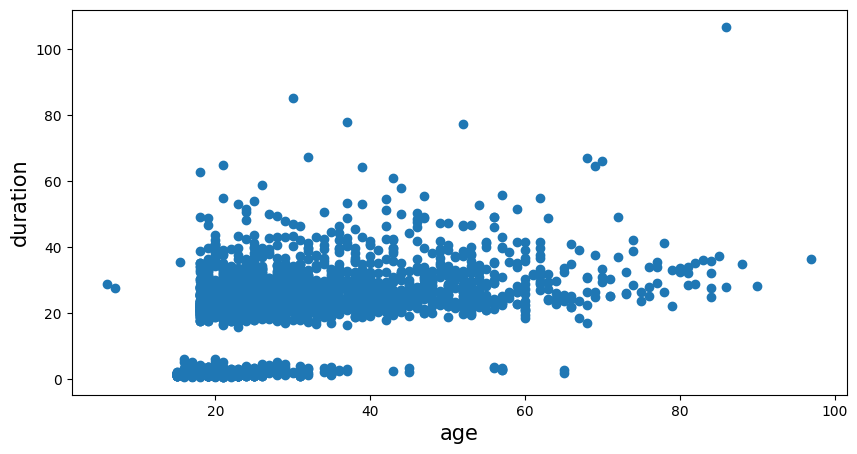

In [ ]:
y.corr(dataset['duration'])
fig, ax = plt.subplots(figsize=(10,5))
plt.plot(y,dataset['duration'],'o')
plt.xlabel('age', fontsize=15)
plt.ylabel('duration', fontsize=15)


In [69]:
dataset


,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,num_words,num_characters,num_pauses,silence_duration,igbo,english,duration
0,1821.69060,3999.7170,145.43066,0.013795,0.082725,0.002254,0.210093,3112.257251,151.999081,-123.999726,69,281,39,23.846893,False,False,35.095238
1,1297.81870,3998.8590,145.37268,0.025349,0.096242,0.007819,0.078849,1688.016389,129.199219,-86.928478,69,281,21,19.388662,False,False,23.331270
2,1332.85240,3998.8025,145.42395,0.019067,0.119456,0.002974,0.105365,2576.901706,117.453835,-98.450670,69,281,1,21.640998,False,False,21.667891
3,1430.34990,3998.4510,147.98083,0.017004,0.102389,0.022371,0.173701,3269.751413,117.453835,-56.459762,69,281,9,19.644127,False,True,22.476939
4,1688.72340,3998.6113,145.44772,0.028027,0.124831,0.005369,0.107279,1930.897375,112.347147,-80.349204,69,281,11,18.041905,False,False,19.090272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2928,1641.14930,3999.1616,145.39359,0.023647,0.115361,0.001879,0.111799,2188.853478,184.570312,-100.921055,69,281,11,17.461406,False,True,20.410748
2929,1089.60050,3984.6550,145.58409,0.015317,0.126740,0.000339,0.070508,2712.362323,83.354335,6.757283,0,0,1,1.509206,True,False,1.509167
2930,994.46484,3989.1785,148.97475,0.009677,0.103535,0.001464,0.058442,2248.698477,89.102909,-53.913449,1,9,1,1.645034,True,False,1.645000
2931,1600.00820,3999.7559,145.36101,0.019571,0.100946,0.004451,0.115139,1834.596924,143.554688,-96.143090,69,281,19,16.346848,False,False,20.708141


In [70]:

x_train, x_test, y_train, y_test = train_test_split(dataset, y, test_size=0.2, random_state=42)
clf = RandomForestRegressor(n_estimators=500, random_state=42)
clf.fit(x_train, y_train)
ypred = clf.predict(x_test)
# print(ypred)
root_mean_squared_error(y_test, ypred)



9.967896232140408

In [71]:
importances = clf.feature_importances_
names = x_train.columns
feature_importances = pd.DataFrame({'feature': names, 'importance': importances}).sort_values(by='importance', ascending=False)


feature_importances

,feature,importance
16,duration,0.315312
13,silence_duration,0.079986
3,jitter,0.066030
7,spectral_centroid_mean,0.057010
5,energy,0.054167
4,shimmer,0.053289
2,min_pitch,0.052590
6,zcr_mean,0.050679
0,mean_pitch,0.049904
1,max_pitch,0.047508


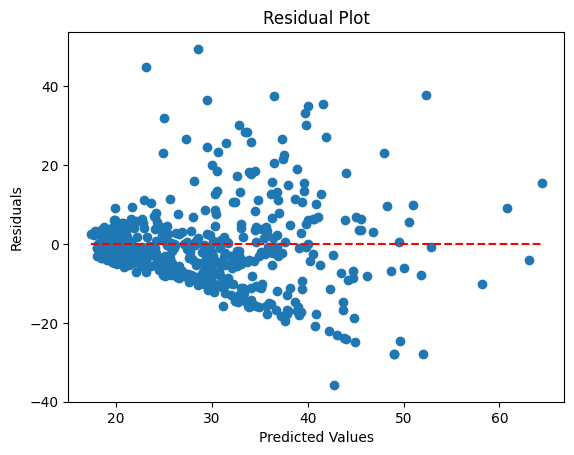

In [72]:
residuals = y_test - ypred
plt.scatter(ypred, residuals)
plt.hlines(0, min(ypred), max(ypred), colors='r', linestyles='dashed')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

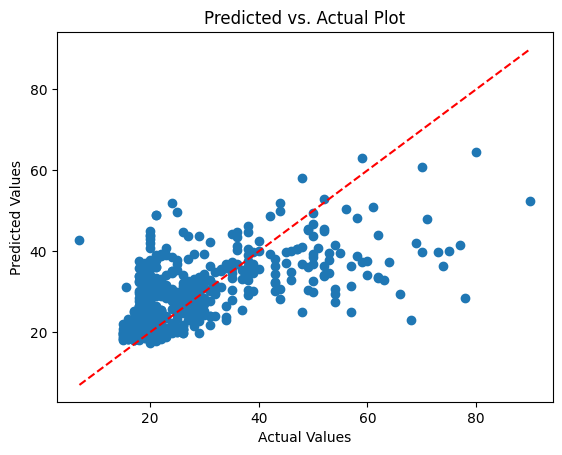

In [73]:
# Predicted vs. Actual Plot
# plt.figsize=(5, 5)
plt.scatter(y_test, ypred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs. Actual Plot')
plt.savefig('naive_model.pdf', format='pdf')
plt.show()


predico troppo alto per i giovani e troppo basso per i vecchi. posso evitare questo comporatamento senza overfittare? 



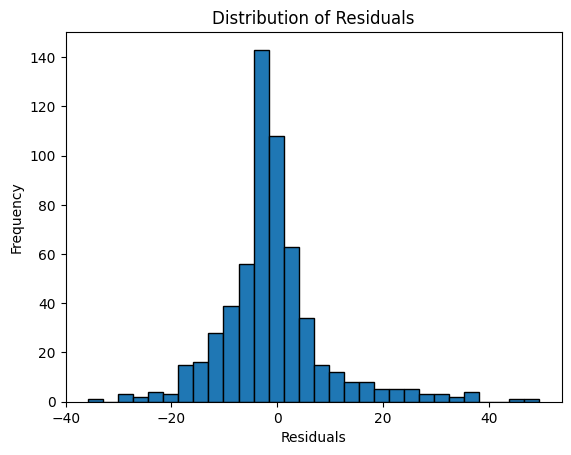

In [74]:
# Distribution of Residuals
plt.hist(residuals, bins=30, edgecolor='k')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()

In [75]:
#divido i residui in gruppi di eta
resdataframe = pd.DataFrame(residuals.values, columns=['residuals'])    
resdataframe['age'] = y_test.values 
resdataframe



,residuals,age
0,0.632,22.0
1,0.456,21.0
2,-18.802,26.0
3,-5.462,20.0
4,-0.966,19.0
...,...,...
582,-1.090,17.0
583,0.380,38.0
584,-1.478,21.0
585,4.254,24.0


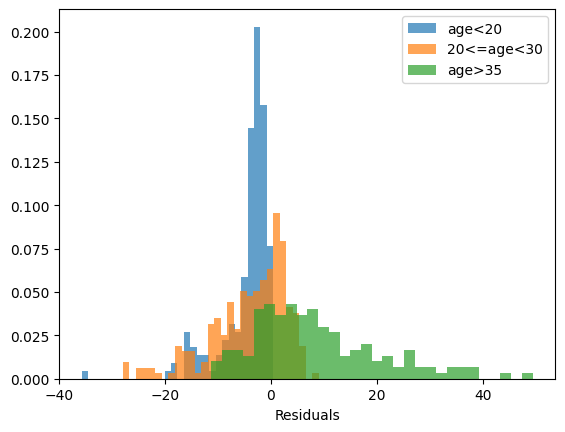

In [76]:
#NOTE: residual is defined as the difference between the actual value and the predicted value,
# a negative residual means that the model overestimated the value, a positive residual means that the model underestimated the value
plt.hist(resdataframe[resdataframe['age']<20]['residuals'], bins=30, alpha=0.7, label='age<20',density=True);
plt.hist(resdataframe[(resdataframe['age']>=20) & (resdataframe['age']<30)]['residuals'], bins=30, alpha=0.7, label='20<=age<30',density=True);
# plt.hist(resdataframe[(resdataframe['age']>=30) & (resdataframe['age']<35)]['residuals'], bins=30, alpha=0.7, label='30<=age<35',density=True);
plt.hist(resdataframe[(resdataframe['age']>=30)]['residuals'], bins=30, alpha=0.7, label='age>35',density=True);

plt.xlabel('Residuals')
plt.legend()
plt.show()

Il problema di questa tecnica è riuscire a non overfittare. gia guardando il taghet non sto facendo bene, vediamo dove mi porta


In [87]:
#ottengo la maggior parte del errore per eta > di 35 anni provero a creare un classificatore per eta < 35 anni, se ottengo buoni score per il classificatore
# provero ad allenare dure regressori diversi
splitting_age = 35
classifier_labels = y < splitting_age
rfclf = RandomForestClassifier(n_estimators=500, random_state=42,n_jobs=-2)

x_train, x_test, y_train, y_test = train_test_split(dataset, classifier_labels, test_size=0.2, random_state=42)
rfclf.fit(x_train, y_train)
age_clf = rfclf.predict(x_test)
rfclf.score(x_test, y_test)






0.8637137989778535

In [78]:
classifier_labels.sum()/classifier_labels.shape[0] ,classifier_labels.sum()

(np.float64(0.7108762359359018), np.int64(2085))

In [82]:
mfccs = functions.extract_mfcc(dev_paths, sampling_rate, n_mfcc=35, filtered=False)

In [83]:
mfccs

,mfcc-0,mfcc-1,mfcc-2,mfcc-3,mfcc-4,mfcc-5,mfcc-6,mfcc-7,mfcc-8,mfcc-9,...,mfcc-25,mfcc-26,mfcc-27,mfcc-28,mfcc-29,mfcc-30,mfcc-31,mfcc-32,mfcc-33,mfcc-34
0,-369.445770,55.719803,-20.172199,1.858431,-11.094159,-21.289921,-6.304841,-15.065480,-22.394066,-9.545800,...,2.483096,0.528495,2.726236,-0.758088,2.696102,0.810756,3.253712,1.093236,4.147623,2.798546
1,-291.229675,122.431282,-5.133554,40.160587,8.176783,-6.416772,-2.469234,-4.796830,3.619060,-9.030071,...,-1.737018,-2.636123,2.310764,-0.498084,0.932835,2.466422,5.123617,5.987349,10.230344,6.999561
2,-304.470520,72.080658,19.171961,23.241703,13.341725,6.166435,4.148386,1.036567,-8.732519,9.563401,...,5.530684,1.677129,8.171193,7.161744,10.407344,5.956420,10.980287,6.030637,2.588548,0.306264
3,-254.585403,38.093533,27.635315,29.920996,-9.363325,-17.644960,-31.449722,-8.642946,-19.032154,-7.290900,...,4.804540,-1.905222,2.257606,-1.490680,10.841923,8.880380,9.293415,5.651877,5.773512,4.439307
4,-273.523865,112.785225,-2.480324,33.589447,28.171324,-3.943830,-0.313671,13.828846,-18.041935,-1.688610,...,-0.573308,-0.644207,-1.381585,-0.915129,-1.893239,-2.785956,0.472536,-0.914049,0.469206,-2.130052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2928,-303.633423,100.347366,-10.533907,42.567596,8.260336,4.166447,-7.835091,-6.514761,2.179604,2.406445,...,0.501216,-3.453966,0.392780,-1.560139,-1.394107,-2.298770,1.153644,-3.459411,0.371645,-3.413815
2929,-333.270264,67.565758,10.775462,23.178925,2.517168,3.602794,10.724029,7.729363,-5.251327,8.498218,...,-2.664257,-3.317295,0.169012,2.495036,16.172787,14.310350,20.550920,12.995621,5.336108,-2.976853
2930,-351.276459,73.475639,27.039822,52.517185,-3.360270,2.510531,13.241141,-4.899483,4.591391,1.474348,...,1.062869,-0.016338,-1.350654,1.840431,1.508776,-2.252435,6.079259,2.355264,6.439105,3.019289
2931,-332.118744,109.372849,-23.515118,28.353584,5.973415,-0.356308,-16.450092,-15.147188,-20.694489,-7.093591,...,-1.024721,-6.825322,-5.647349,-5.124072,-2.137633,-2.594735,-7.468062,-4.089187,-5.827564,-6.147809


In [88]:
dataset_copy = dataset.copy()
dataset = pd.concat([dataset, mfccs], axis=1)

In [89]:
#devo cercare di avre abbstaza dati per creare due regressori devo trovare il range giusto di eta
x_train_clf, x_test_clf, y_train_clf, y_test_clf  = train_test_split(dataset,y < splitting_age, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=500, random_state=42,n_jobs=-2)
clf.fit(x_train_clf, y_train_clf)

X_train, X_test, y_train, y_test  = train_test_split(dataset, y, test_size=0.2, random_state=42)



#divido il dataset in due parti una per eta < splitting_age e una per eta > splitting_age
x_train_young = x_train[y_train<splitting_age]
x_train_old = x_train[y_train>=splitting_age]


y_train_young = y_train[y_train<splitting_age]
y_train_old = y_train[y_train>=splitting_age]

young_reg = RandomForestRegressor(n_estimators=500, random_state=42)
young_reg.fit(x_train_young, y_train_young)


old_reg = RandomForestRegressor(n_estimators=500, random_state=42)
old_reg.fit(x_train_old, y_train_old)

#devo predirre le ete e dare i dati in pasto ai due modelli di regressione

age_classification = clf.predict(x_test_clf)
print(clf.score(x_test_clf, y_test_clf))

x_test_young = x_test[age_classification]
x_test_old = x_test[~age_classification]

y_test_young = y_test[age_classification]
y_test_old = y_test[~age_classification]

ypred_young = young_reg.predict(x_test_young)
print('rmse young->',root_mean_squared_error(y_test_young, ypred_young))

ypred_old = old_reg.predict(x_test_old)
print('rmse old->',root_mean_squared_error(y_test_old, ypred_old))

ypred = np.zeros(y_test.shape[0])
ypred[age_classification] = ypred_young
ypred[~age_classification] = ypred_old

root_mean_squared_error(y_test, ypred)
 







 


0.8705281090289608
rmse young-> 9.299936689027613
rmse old-> 15.508210601269681


10.30374485626621

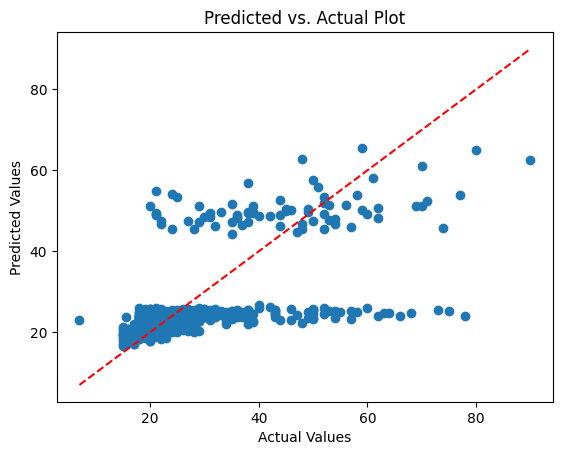

In [90]:
# Predicted vs. Actual Plot
plt.scatter(y_test, ypred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs. Actual Plot')
# plt.savefig('age_divided.pdf', format='pdf')
plt.show()


Non ho fatto un bell affare non funziona bene. il classificatore nn è in grado di dividere bene i dati,vengono dati in pasto al modello sbagliato 

In [130]:
#replace the total energy with the energy per second
dataset['energy'] = [dataset.iloc[i]['energy']/dataset.iloc[i]['duration'] for i in range(dataset.shape[0])]

dataset['words_per_sec'] = [dataset.iloc[i]['num_words']/dataset.iloc[i]['duration'] for i in range(dataset.shape[0])]
dataset['characters_per_sec'] = [dataset.iloc[i]['num_characters']/dataset.iloc[i]['duration'] for i in range(dataset.shape[0])]
dataset.drop(columns=['num_words','num_characters'], inplace=True)
# bassa correlazione not very usefull

In [131]:
dataset_copy = dataset.copy()

In [132]:
dataset = dataset_copy.copy()

In [133]:
dataset.drop(columns=['english'], inplace=True)

In [134]:
formants = pd.read_csv('formants_1234.csv')  

In [135]:
formants 

,f1_mean,f2_mean,f3_mean,f4_mean,f1_std,f2_std,f3_std,f4_std
0,958.058106,2300.579078,3552.518114,4453.071120,444.773232,542.045063,515.176894,377.684029
1,866.092331,2393.467663,3506.899921,4536.792782,581.026823,531.768740,622.415974,208.600262
2,1008.034349,2506.377126,3782.403795,4411.484747,553.367597,668.096942,590.920625,390.624249
3,876.812634,2488.497669,3633.933193,4785.691942,630.690983,640.082214,677.439794,251.932105
4,925.597139,2228.153142,3131.679790,3797.387433,520.007599,500.690366,421.131723,392.813433
...,...,...,...,...,...,...,...,...
2928,1004.672755,2255.526612,3412.410589,4150.545429,513.184444,426.122434,505.801747,250.639250
2929,1036.866260,2477.390677,3645.294054,4640.655343,611.584481,587.296948,458.920771,293.404720
2930,1024.907815,2748.041709,3977.493120,4771.642055,777.732216,553.303267,401.334306,226.101193
2931,755.469464,1969.003848,3110.843054,3906.910999,458.165921,459.840833,553.907832,366.321708


ABBIAMO CALCOLATO GLI HNR SONO UGUALI A QUELLI CHE GIA ABBIAMO 

In [136]:
#posso risparmiare del tempo non leggendo ogni volta i file audio, in functions ma ok abbiamo deciso di salvare tutto in csv

In [137]:
def compute_some_features(dev_paths,sampling_rate):
    peak_freq = functions.compute_peak_frequency(dev_paths, sampling_rate)
    temporal_median = functions.compute_temporal_median(dev_paths, sampling_rate)
    pitch_vls = functions.compute_pitch_attributes(dev_paths, sampling_rate)
    entropy = functions.compute_entropy(dev_paths, sampling_rate)   
    return pd.concat([peak_freq, temporal_median, pitch_vls,entropy],axis=1)


In [138]:
# additional_features = compute_some_features(dev_paths, sampling_rate)
# additional_features.to_csv('peak_freq_entropy_pitch_feature.csv',index=False)

In [139]:
additional_features = pd.read_csv('peak_freq_entropy_pitch_feature.csv')


In [140]:
additional_features

,peak_freq,peak_amplitude,temporal_median,nVoicedFrames,meanAbsoluteSlope,nFrames,entropy
0,555.664062,0.000434,0.046026,797.0,1026.152455,1751.0,0.809055
1,210.132812,0.003226,0.112830,679.0,786.118223,1163.0,0.872433
2,249.265625,0.001037,0.086232,572.0,950.342636,1080.0,0.873387
3,244.265625,0.008087,0.283693,707.0,784.067480,1120.0,0.911091
4,202.132812,0.001625,0.122995,492.0,561.839239,951.0,0.887211
...,...,...,...,...,...,...,...
2928,141.132812,0.000460,0.084476,526.0,518.669316,1017.0,0.871634
2929,868.195312,0.000073,0.031989,59.0,2037.071939,72.0,0.824046
2930,429.531250,0.000408,0.048325,59.0,750.955892,79.0,0.781826
2931,440.531250,0.001617,0.090937,599.0,518.238324,1032.0,0.862373


In [141]:
dataset = pd.concat([dataset,additional_features], axis=1)
# dataset = pd.concat([dataset,formants,additional_features], axis=1)

In [142]:
pyin = pd.read_csv('pyin_results_cleaned.csv')
pyin.drop(columns=['file_name'], inplace=True)


In [143]:
dataset.columns

Index(['mean_pitch', 'max_pitch', 'min_pitch', 'jitter', 'shimmer', 'energy',
       'zcr_mean', 'spectral_centroid_mean', 'tempo', 'hnr', 'num_pauses',
       'silence_duration', 'duration', 'mfcc-0', 'mfcc-1', 'mfcc-2', 'mfcc-3',
       'mfcc-4', 'mfcc-5', 'mfcc-6', 'mfcc-7', 'mfcc-8', 'mfcc-9', 'mfcc-10',
       'mfcc-11', 'mfcc-12', 'mfcc-13', 'mfcc-14', 'mfcc-15', 'mfcc-16',
       'mfcc-17', 'mfcc-18', 'mfcc-19', 'mfcc-20', 'mfcc-21', 'mfcc-22',
       'mfcc-23', 'mfcc-24', 'mfcc-25', 'mfcc-26', 'mfcc-27', 'mfcc-28',
       'mfcc-29', 'mfcc-30', 'mfcc-31', 'mfcc-32', 'mfcc-33', 'mfcc-34',
       'words_per_sec', 'characters_per_sec', 'peak_freq', 'peak_amplitude',
       'temporal_median', 'nVoicedFrames', 'meanAbsoluteSlope', 'nFrames',
       'entropy'],
      dtype='object')

In [144]:
clf = functions.try_model(dataset, y)
functions.print_feature_importance(clf, dataset)

9.622345584676975
                   feature  importance
12                duration    0.201560
55                 nFrames    0.069677
11        silence_duration    0.047827
40                 mfcc-27    0.029854
53           nVoicedFrames    0.026899
17                  mfcc-4    0.025959
19                  mfcc-6    0.025845
3                   jitter    0.025798
54       meanAbsoluteSlope    0.023406
44                 mfcc-31    0.018887
20                  mfcc-7    0.014961
42                 mfcc-29    0.014773
4                  shimmer    0.013798
23                 mfcc-10    0.013540
46                 mfcc-33    0.013128
43                 mfcc-30    0.012934
37                 mfcc-24    0.012784
26                 mfcc-13    0.012745
22                  mfcc-9    0.012564
0               mean_pitch    0.012427
35                 mfcc-22    0.012376
2                min_pitch    0.012270
15                  mfcc-2    0.012250
18                  mfcc-5    0.011493
36     

In [145]:
dataset.fillna(dataset['entropy'].max(), inplace=True)

In [147]:


from sklearn.preprocessing import StandardScaler,RobustScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

pipe = make_pipeline(StandardScaler(), SVR())
param_grid = {'svr__C': [0.1, 1, 10, 100], 'svr__gamma': [0.1, 1, 10, 100], 'svr__kernel': ['rbf', 'poly', 'sigmoid']}

grid = GridSearchCV(pipe, param_grid, cv=5,n_jobs=-2)
# best = grid.fit(dataset, y)


In [148]:
# best.best_params_

In [149]:
pipe = make_pipeline(StandardScaler(),SVR())
pipe.fit(x_train, y_train)
ypred = pipe.predict(x_test)
print(root_mean_squared_error(y_test, ypred))

10.419685568558382


In [150]:
clf.get_params

<bound method BaseEstimator.get_params of GradientBoostingRegressor(n_estimators=500, random_state=42)>

In [151]:
#try to find the best hyperparameters for the random forest regressor



grid = {
    'n_estimators': [500],
    'max_depth': [None, 10, ],
    'max_features': ['log2', 'sqrt'],
    'min_samples_leaf': 4,
    'min_samples_split': 4,
    
}
grid_cv = GridSearchCV(RandomForestRegressor(), grid, cv=5, return_train_score=True, verbose=3, n_jobs=-2,scoring='neg_root_mean_squared_error')


In [154]:
#trying to eval the model 
eval_set = pd.read_csv('evaluation.csv')
eval_paths = eval_set['path']

In [155]:
(eval_set['ethnicity']== 'english').sum()

np.int64(0)

In [156]:
eval_set['english'] = [False for i in range(eval_set.shape[0])]

In [157]:
duration_eval = functions.extract_audio_duration(eval_paths,filtered= False)

In [158]:
eval_set.columns

Index(['Id', 'sampling_rate', 'gender', 'ethnicity', 'mean_pitch', 'max_pitch',
       'min_pitch', 'jitter', 'shimmer', 'energy', 'zcr_mean',
       'spectral_centroid_mean', 'tempo', 'hnr', 'num_words', 'num_characters',
       'num_pauses', 'silence_duration', 'path', 'english'],
      dtype='object')

In [159]:
import csv


def store_formants_1234(dataset:pd.DataFrame, path='audios_development/',  filename='formants_1234.csv', mod = False):
    with open(filename, mode="w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(['f1_mean','f2_mean','f3_mean','f4_mean','f1_std','f2_std','f3_std','f4_std'])
        for i in range(1, len(dataset) + 1):
            sound = pm.Sound(f'{path}{i}.wav')
            if not mod:
                if dataset.loc[i-1,'gender'] == 0:
                    formant = sound.to_formant_burg(time_step=0.02, max_number_of_formants=4, maximum_formant=5000) 
                    # maximum formant for men is lower than for female
                else:
                    formant = sound.to_formant_burg(time_step=0.02, max_number_of_formants=4, maximum_formant=5500)
            else:
                formant = sound.to_formant_burg(time_step=0.02, max_number_of_formants=4, maximum_formant=5000) 
        
            formants = []
            for time in np.arange(0, sound.duration, 0.02):
                f1 = formant.get_value_at_time(1, time)  # First formant (F1)
                f2 = formant.get_value_at_time(2, time)  # Second formant (F2)
                f3 = formant.get_value_at_time(3, time)  # Third formant (F3)
                f4 = formant.get_value_at_time(4, time)  # Fourth formant (F4)
                formants.append([f1, f2, f3, f4])

            formants = np.array(formants) 
            writer.writerow(np.vstack([np.nanmean(formants, axis=0), np.nanstd(formants, axis=0)]).flatten())

def get_formants_1234(dataset:pd.DataFrame, path='audios_development/',  filename='formants_1234.csv', mod=False):
    try:
        with open(filename, mode='r', newline="") as file:
            reader = csv.reader(file)
            header = next(reader)
            data = [row for row in reader]
            data = pd.DataFrame(data, columns=header)
    except:
        store_formants_1234(dataset, path,  filename, mod)
        with open(filename, mode='r', newline="") as file:
            reader = csv.reader(file)
            header = next(reader)
            data = [row for row in reader]
            data = pd.DataFrame(data, columns=header)
    return data

In [160]:

# dataset = pd.read_csv('development.csv')
colums_to_drop = ['path', 'sampling_rate','Id','gender','ethnicity']

#usa i primi n 
# dataset = one_hot_ethnicity(dataset, 1, sorted_etn)


#use only the eanglish language accrocchio strano non mi aspettavo fosse cosi 
# eval_set = one_hot_ethnicity(eval_set, 1, sorted_etn.iloc[1:])

# eval_set = encode_gendedr(dataset)

eval_set = drop_cols(eval_set, colums_to_drop)
eval_set = make_tempo_float(eval_set)

eval_set['duration'] = duration_eval  
 

In [161]:
eval_mfccs = functions.extract_mfcc(eval_paths, sampling_rate, n_mfcc=35, filtered=False)


In [162]:
eval_set = pd.concat([eval_set, eval_mfccs], axis=1)

In [163]:
eval_set['energy'] = [eval_set.iloc[i]['energy']/eval_set.iloc[i]['duration'] for i in range(eval_set.shape[0])]

eval_set['words_per_sec'] = eval_set['num_words']/eval_set['duration']
eval_set['characters_per_sec'] = eval_set['num_characters']/eval_set['duration']
eval_set.drop(columns=['num_words','num_characters'], inplace=True)

In [164]:
# store_formants_1234(eval_set, path='audios_evaluation/',  filename='formants_1234_eval.csv', mod = True)

In [165]:
eval_additional_features = compute_some_features(eval_paths, sampling_rate)

c:\Users\aleky\Desktop\uni magistrale\data lab\proggetto\Data-Science-Lab\functions.py:199: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, serie.to_frame().T], ignore_index=True)
c:\Users\aleky\Desktop\uni magistrale\data lab\proggetto\.venv\Lib\site-packages\maad\util\math_func.py:439: RuntimeWarning: divide by zero encountered in log
  H = -np.sum(pmf*np.log(pmf),axis)/np.log(n)
c:\Users\aleky\Desktop\uni magistrale\data lab\proggetto\.venv\Lib\site-packages\maad\util\math_func.py:439: RuntimeWarning: invalid value encountered in multiply
  H = -np.sum(pmf*np.log(pmf),axis)/np.log(n)


In [166]:
eval_formants = get_formants_1234(eval_set, path= 'audios_evaluation', filename='formants_1234_eval.csv', mod=True)

In [167]:
eval_formants

,f1_mean,f2_mean,f3_mean,f4_mean,f1_std,f2_std,f3_std,f4_std
0,1077.3936614554877,2434.563528812768,3578.299071215795,3979.608189730282,601.879253304464,639.6405752670848,557.8118107084326,286.36622428894464
1,930.23320868878,2302.803092925674,3518.948153488816,4259.369959225039,572.2174755704267,565.3917688160594,540.3364800689712,305.73104401677034
2,843.8967542825736,2151.09867640849,3343.3662899118176,4309.894437480483,336.7777870880954,332.0420204250956,448.526962303867,268.80791472457435
3,829.882670728795,2114.784690740058,3236.769375241931,4084.648972437805,509.3492818018123,541.8500772990807,505.7896000568164,274.84182524269704
4,988.1217620947098,2310.760073356146,3475.556622438119,4030.8763964868585,504.2735656723258,499.9694473578603,400.50149831319044,379.1326618939566
...,...,...,...,...,...,...,...,...
686,667.9120442466831,2113.22230369334,3152.067981750726,3928.0663704374233,381.1402150915851,567.9806430429569,557.7657340541856,234.73376435783348
687,1611.2888418887494,2802.5452138164264,3499.67787003298,3901.1052194956087,881.3980707604397,565.0491130254204,423.33061222816457,217.94267536960274
688,803.7048149201211,2136.7507865550415,3414.6392122562906,4317.4939758818755,497.6772335841185,543.3836353436756,508.7745804356002,194.95795910117624
689,1039.6817851698306,2357.7100281444577,3473.4563934319367,4233.7576389614815,461.1868278625198,446.9809084445458,388.21114549022997,319.5231182302926


In [168]:
# eval_set = pd.concat([eval_set, eval_formants,eval_additional_features], axis=1)
eval_set = pd.concat([eval_set,eval_additional_features], axis=1)


In [169]:
eval_set.drop(columns=['english'], inplace=True)

In [170]:
eval_set.columns, dataset.columns

(Index(['mean_pitch', 'max_pitch', 'min_pitch', 'jitter', 'shimmer', 'energy',
        'zcr_mean', 'spectral_centroid_mean', 'tempo', 'hnr', 'num_pauses',
        'silence_duration', 'duration', 'mfcc-0', 'mfcc-1', 'mfcc-2', 'mfcc-3',
        'mfcc-4', 'mfcc-5', 'mfcc-6', 'mfcc-7', 'mfcc-8', 'mfcc-9', 'mfcc-10',
        'mfcc-11', 'mfcc-12', 'mfcc-13', 'mfcc-14', 'mfcc-15', 'mfcc-16',
        'mfcc-17', 'mfcc-18', 'mfcc-19', 'mfcc-20', 'mfcc-21', 'mfcc-22',
        'mfcc-23', 'mfcc-24', 'mfcc-25', 'mfcc-26', 'mfcc-27', 'mfcc-28',
        'mfcc-29', 'mfcc-30', 'mfcc-31', 'mfcc-32', 'mfcc-33', 'mfcc-34',
        'words_per_sec', 'characters_per_sec', 'peak_freq', 'peak_amplitude',
        'temporal_median', 'nVoicedFrames', 'meanAbsoluteSlope', 'duration',
        'nFrames', 'entropy'],
       dtype='object'),
 Index(['mean_pitch', 'max_pitch', 'min_pitch', 'jitter', 'shimmer', 'energy',
        'zcr_mean', 'spectral_centroid_mean', 'tempo', 'hnr', 'num_pauses',
        'silence_duration

In [171]:
eval_set = pd.concat([eval_set.iloc[:, :-3], eval_set.iloc[:, -2:]], axis=1)

In [172]:
eval_set.columns == dataset.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [174]:
clf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1,min_samples_leaf=4,min_samples_split=4)
clf.fit(dataset, y)
ypred = clf.predict(eval_set)

In [175]:
from sklearn.ensemble import HistGradientBoostingRegressor

pd.Series(HistGradientBoostingRegressor().fit(dataset, y).predict(eval_set), name='Predicted').to

AttributeError: 'Series' object has no attribute 'to'

In [471]:
pred_df = pd.DataFrame(ypred, columns=['Predicted'])

# pred['Id'] = eval_set.index
pred_df

,Predicted
0,37.285437
1,33.119612
2,23.778682
3,30.252865
4,36.615166
...,...
686,23.423328
687,24.859494
688,32.522852
689,29.845788


In [472]:
pred_df.to_csv('../submitions/pred_added_rf.csv', index=True, index_label='Id')

non cambia niente se facciamo il round probabilmente lo fanno loro prima di calcolare l'errore

score_terribbile 10.052 la colonna inglese non è servita a un cazz non c'è nel eval


In [ ]:
dataset

,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,...,f2_std,f3_std,f4_std,peak_freq,peak_amplitude,temporal_median,nVoicedFrames,meanAbsoluteSlope,nFrames,entropy
0,1821.69060,3999.7170,145.43066,0.013795,0.082725,0.000064,0.210093,3112.257251,151.999081,-123.999726,...,542.045063,515.176894,377.684029,555.664062,0.000434,0.046026,797.0,1026.152455,1751.0,0.809055
1,1297.81870,3998.8590,145.37268,0.025349,0.096242,0.000335,0.078849,1688.016389,129.199219,-86.928478,...,531.768740,622.415974,208.600262,210.132812,0.003226,0.112830,679.0,786.118223,1163.0,0.872433
2,1332.85240,3998.8025,145.42395,0.019067,0.119456,0.000137,0.105365,2576.901706,117.453835,-98.450670,...,668.096942,590.920625,390.624249,249.265625,0.001037,0.086232,572.0,950.342636,1080.0,0.873387
3,1430.34990,3998.4510,147.98083,0.017004,0.102389,0.000995,0.173701,3269.751413,117.453835,-56.459762,...,640.082214,677.439794,251.932105,244.265625,0.008087,0.283693,707.0,784.067480,1120.0,0.911091
4,1688.72340,3998.6113,145.44772,0.028027,0.124831,0.000281,0.107279,1930.897375,112.347147,-80.349204,...,500.690366,421.131723,392.813433,202.132812,0.001625,0.122995,492.0,561.839239,951.0,0.887211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2928,1641.14930,3999.1616,145.39359,0.023647,0.115361,0.000092,0.111799,2188.853478,184.570312,-100.921055,...,426.122434,505.801747,250.639250,141.132812,0.000460,0.084476,526.0,518.669316,1017.0,0.871634
2929,1089.60050,3984.6550,145.58409,0.015317,0.126740,0.000225,0.070508,2712.362323,83.354335,6.757283,...,587.296948,458.920771,293.404720,868.195312,0.000073,0.031989,59.0,2037.071939,72.0,0.824046
2930,994.46484,3989.1785,148.97475,0.009677,0.103535,0.000890,0.058442,2248.698477,89.102909,-53.913449,...,553.303267,401.334306,226.101193,429.531250,0.000408,0.048325,59.0,750.955892,79.0,0.781826
2931,1600.00820,3999.7559,145.36101,0.019571,0.100946,0.000215,0.115139,1834.596924,143.554688,-96.143090,...,459.840833,553.907832,366.321708,440.531250,0.001617,0.090937,599.0,518.238324,1032.0,0.862373


In [870]:
# dataset.drop(columns=['duration'], inplace=True)

In [416]:
dataset

,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,...,f3_std,f4_std,peak_freq,peak_amplitude,temporal_median,nVoicedFrames,meanAbsoluteSlope,duration,nFrames,entropy
0,1821.69060,3999.7170,145.43066,0.013795,0.082725,0.000064,0.210093,3112.257251,151.999081,-123.999726,...,515.176894,377.684029,555.664062,0.000434,0.046026,797.0,1026.152455,17.547619,1751.0,0.809055
1,1297.81870,3998.8590,145.37268,0.025349,0.096242,0.000335,0.078849,1688.016389,129.199219,-86.928478,...,622.415974,208.600262,210.132812,0.003226,0.112830,679.0,786.118223,11.665646,1163.0,0.872433
2,1332.85240,3998.8025,145.42395,0.019067,0.119456,0.000137,0.105365,2576.901706,117.453835,-98.450670,...,590.920625,390.624249,249.265625,0.001037,0.086232,572.0,950.342636,10.833946,1080.0,0.873387
3,1430.34990,3998.4510,147.98083,0.017004,0.102389,0.000995,0.173701,3269.751413,117.453835,-56.459762,...,677.439794,251.932105,244.265625,0.008087,0.283693,707.0,784.067480,11.238481,1120.0,0.911091
4,1688.72340,3998.6113,145.44772,0.028027,0.124831,0.000281,0.107279,1930.897375,112.347147,-80.349204,...,421.131723,392.813433,202.132812,0.001625,0.122995,492.0,561.839239,9.545147,951.0,0.887211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2928,1641.14930,3999.1616,145.39359,0.023647,0.115361,0.000092,0.111799,2188.853478,184.570312,-100.921055,...,505.801747,250.639250,141.132812,0.000460,0.084476,526.0,518.669316,10.205374,1017.0,0.871634
2929,1089.60050,3984.6550,145.58409,0.015317,0.126740,0.000225,0.070508,2712.362323,83.354335,6.757283,...,458.920771,293.404720,868.195312,0.000073,0.031989,59.0,2037.071939,0.754603,72.0,0.824046
2930,994.46484,3989.1785,148.97475,0.009677,0.103535,0.000890,0.058442,2248.698477,89.102909,-53.913449,...,401.334306,226.101193,429.531250,0.000408,0.048325,59.0,750.955892,0.822517,79.0,0.781826
2931,1600.00820,3999.7559,145.36101,0.019571,0.100946,0.000215,0.115139,1834.596924,143.554688,-96.143090,...,553.907832,366.321708,440.531250,0.001617,0.090937,599.0,518.238324,10.354082,1032.0,0.862373


In [474]:
from sklearn.ensemble import HistGradientBoostingRegressor
X_train, X_test, y_train, y_test = train_test_split(dataset, y, test_size=0.2, random_state=42)
clf = HistGradientBoostingRegressor(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)
ypred = clf.predict(X_test)
print(root_mean_squared_error(y_test, ypred))

9.49107068637873


In [475]:
HistGradientBoostingRegressor()
param_grid = {
    'max_iter': [1000],
    'max_depth': [None, 10, 20],
    # 'max_leaf_nodes': [31, 64, 128],
    'learning_rate': [0.01],
    'l2_regularization': [0, 0.1, 0.01]
}
grid_cv = GridSearchCV(HistGradientBoostingRegressor(), param_grid, cv=5, return_train_score=True, verbose=3, n_jobs=-2)
# best = grid_cv.fit(dataset, y)

In [178]:
# best.best_params_, best.best_score_

({'l2_regularization': 0.1,
  'learning_rate': 0.01,
  'max_depth': None,
  'max_iter': 1000},
 np.float64(0.3921881995553794))

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(dataset, y, test_size=0.2, random_state=42)
clf = HistGradientBoostingRegressor(l2_regularization=0.1,
  learning_rate=0.01,
  max_depth=None,
  max_iter=1000)
# clf.fit(x_train, y_train)
# ypred = clf.predict(x_test)
print(root_mean_squared_error(y_test, ypred))
clf.fit(dataset, y)


ValueError: Found input variables with inconsistent numbers of samples: [587, 691]

In [479]:
ypred = clf.predict(eval_set)

NotFittedError: This HistGradientBoostingRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [480]:
pred_df = pd.DataFrame(ypred, columns=['Predicted'])

# pred['Id'] = eval_set.index
pred_df

,Predicted
0,37.206030
1,35.817975
2,24.500570
3,29.787343
4,39.707591
...,...
686,22.970532
687,23.836609
688,33.466345
689,30.761902


In [188]:
pred_df.to_csv('../submitions/pred_histGrad.csv', index=True, index_label='Id')

In [481]:
from sklearn.ensemble import VotingRegressor
randomforest = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1,min_samples_leaf=4,min_samples_split=4)
hist = HistGradientBoostingRegressor(l2_regularization=0.1,learning_rate=0.01,max_depth=None,max_iter=1000)
# VotingRegressor(randomforest, hist)
clf = VotingRegressor([('rf', randomforest), ('hist', hist)])
x_train, x_test, y_train, y_test = train_test_split(dataset, y, test_size=0.2, random_state=42)
clf.fit(x_train, y_train)
ypred = clf.predict(x_test)
print(root_mean_squared_error(y_test, ypred))


9.39988237459385


In [482]:
clf = VotingRegressor([('rf', randomforest), ('hist', hist)])
clf.fit(dataset, y)
ypred = clf.predict(eval_set)
pred_df = pd.DataFrame(ypred, columns=['Predicted'])
pred_df


,Predicted
0,37.688933
1,34.998950
2,23.659381
3,28.442236
4,36.740895
...,...
686,23.003735
687,24.804620
688,31.851289
689,29.631817


In [484]:
pred_df.to_csv('../submitions/added_fe_ensamble.csv', index=True, index_label='Id')

In [ ]:


x_train, x_test, y_train, y_test = train_test_split(dataset, y, test_size=0.2, random_state=42)
clf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1,min_samples_leaf=4,min_samples_split=4)
clf.fit(x_train, y_train)
ypred = clf.predict(x_test)
ypred = np.round(ypred)
print(root_mean_squared_error(y_test, ypred))

functions.print_feature_importance(clf,dataset) 



9.562067484734852
                   feature  importance
12                duration    0.115395
63                duration    0.114704
11        silence_duration    0.045608
64                 nFrames    0.042877
40                 mfcc-27    0.027852
3                   jitter    0.024227
61           nVoicedFrames    0.023554
17                  mfcc-4    0.022773
19                  mfcc-6    0.022323
53                 f4_mean    0.019724
62       meanAbsoluteSlope    0.017884
44                 mfcc-31    0.017700
42                 mfcc-29    0.014042
4                  shimmer    0.012992
20                  mfcc-7    0.012929
57                  f4_std    0.012676
46                 mfcc-33    0.012291
37                 mfcc-24    0.011984
26                 mfcc-13    0.011676
43                 mfcc-30    0.011445
23                 mfcc-10    0.011214
35                 mfcc-22    0.010957
55                  f2_std    0.010636
15                  mfcc-2    0.010602
41     

In [485]:
dataset

,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,...,f2_std,f3_std,f4_std,peak_freq,peak_amplitude,temporal_median,nVoicedFrames,meanAbsoluteSlope,nFrames,entropy
0,1821.69060,3999.7170,145.43066,0.013795,0.082725,0.000064,0.210093,3112.257251,151.999081,-123.999726,...,542.045063,515.176894,377.684029,555.664062,0.000434,0.046026,797.0,1026.152455,1751.0,0.809055
1,1297.81870,3998.8590,145.37268,0.025349,0.096242,0.000335,0.078849,1688.016389,129.199219,-86.928478,...,531.768740,622.415974,208.600262,210.132812,0.003226,0.112830,679.0,786.118223,1163.0,0.872433
2,1332.85240,3998.8025,145.42395,0.019067,0.119456,0.000137,0.105365,2576.901706,117.453835,-98.450670,...,668.096942,590.920625,390.624249,249.265625,0.001037,0.086232,572.0,950.342636,1080.0,0.873387
3,1430.34990,3998.4510,147.98083,0.017004,0.102389,0.000995,0.173701,3269.751413,117.453835,-56.459762,...,640.082214,677.439794,251.932105,244.265625,0.008087,0.283693,707.0,784.067480,1120.0,0.911091
4,1688.72340,3998.6113,145.44772,0.028027,0.124831,0.000281,0.107279,1930.897375,112.347147,-80.349204,...,500.690366,421.131723,392.813433,202.132812,0.001625,0.122995,492.0,561.839239,951.0,0.887211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2928,1641.14930,3999.1616,145.39359,0.023647,0.115361,0.000092,0.111799,2188.853478,184.570312,-100.921055,...,426.122434,505.801747,250.639250,141.132812,0.000460,0.084476,526.0,518.669316,1017.0,0.871634
2929,1089.60050,3984.6550,145.58409,0.015317,0.126740,0.000225,0.070508,2712.362323,83.354335,6.757283,...,587.296948,458.920771,293.404720,868.195312,0.000073,0.031989,59.0,2037.071939,72.0,0.824046
2930,994.46484,3989.1785,148.97475,0.009677,0.103535,0.000890,0.058442,2248.698477,89.102909,-53.913449,...,553.303267,401.334306,226.101193,429.531250,0.000408,0.048325,59.0,750.955892,79.0,0.781826
2931,1600.00820,3999.7559,145.36101,0.019571,0.100946,0.000215,0.115139,1834.596924,143.554688,-96.143090,...,459.840833,553.907832,366.321708,440.531250,0.001617,0.090937,599.0,518.238324,1032.0,0.862373


In [725]:
dataset['age'] = y
corr_age = dataset.corr()['age']
dataset.drop(columns=['age'], inplace=True) 
corr_age = np.abs(corr_age).sort_values(ascending=False)
corr_age.drop(index='age', inplace=True)    
corr_age

duration                  0.532764
silence_duration          0.514127
hnr                       0.446880
num_pauses                0.437670
mfcc-6                    0.393752
mean_pitch                0.315645
mfcc-13                   0.315284
mfcc-15                   0.296953
mfcc-17                   0.282570
mfcc-33                   0.280580
zcr_mean                  0.278430
mfcc-31                   0.276217
mfcc-11                   0.257834
mfcc-8                    0.254957
english                   0.249463
jitter                    0.238498
mfcc-2                    0.232971
max_pitch                 0.226643
mfcc-29                   0.226317
mfcc-9                    0.224809
min_pitch                 0.224201
mfcc-27                   0.220519
mfcc-22                   0.212102
shimmer                   0.204140
mfcc-20                   0.194633
energy                    0.180639
mfcc-30                   0.180022
mfcc-4                    0.174676
mfcc-32             

only eanglish seam to be important as a ethnic group, this is maybe because the audio are only on english. and with the column you can say if someone is a native speaker or not.

NON ho racimolato molte informazioni, provo ad aggiungere gli MCC

file lenths 
- max = 2 349 119 
- min = 14 737 
- mean =  366 551

Looking at the plot you can cut at  1 000 000 without loosing inofrmation

In [143]:
# #devo estrarre tutti gli audio e renderli tutti della stessa lunghezza
# desired_legth = int(1e5)

# window = 15000 #i can modify this parameter 

# y = np.zeros(desired_legth)
# audios =  pd.DataFrame([np.zeros(int(desired_legth/window +1))], columns=[f"{i}" for i in range(int(desired_legth/window)+1)] ) 
# for file , i in enumerate(dev_paths):
#     y, sr = librosa.load(file, sr=sampling_rate)
    
    
#     #paddo con zeri e faccio la media a gruppi di 10
#     if len(y) < desired_legth:
#         y = np.pad(y, (0, desired_legth-len(y)), 'constant')
#     elif (len(y) > desired_legth):
#         y = y[:desired_legth]
    
#     mean_y = [np.mean(y[i: i+window]) for i in range(0, len(y), window)]
#     audios.iloc[i] = mean_y    
#     #temp_df = pd.DataFrame([mean_y], columns=[f"{i}" for i in range(int(desired_legth/window)+1)], index=[file]  ) 

        
#     # temp_df = pd.DataFrame(mean_y, columns=['audio'])
#     # 
#     #audios = pd.concat([audios, temp_df], ignore_index=True)
#     if(i%100 == 0):
#         print(i)
#     break
# non va probabilmente casini con i dataframe 

In [313]:
# #for each file i extract a the mfcc i will first rempve the noise from the audio file

# audios = {}
# for file in dev_paths:
#     y_file,r = librosa.load(file, sr=sampling_rate)
#     reduced_noise = nr.reduce_noise(y=y_file, sr=r, stationary=False)
    
#     y_file , _= librosa.effects.trim(reduced_noise, top_db=20)
#     audios[file] = librosa.feature.mfcc(y=y_file, sr=r, n_mfcc=13) 
# temp = audios.copy()
# #dovrei salvare le y_file per non ricalcolare tutto ogni volta è stato luuungooo

In [329]:
# def resize_matrix_with_mean(matrix, target_columns):
#     # Get the original number of columns
#     original_columns = matrix.shape[1]
    
#     # Calculate the chunk size based on the target number of columns
#     chunk_size = original_columns / target_columns
    
#     # Create a new matrix by applying the resize operation row by row
#     resized_matrix = np.array([
#         [
#             np.mean(row[int(i * chunk_size):int((i + 1) * chunk_size)]) 
#             for i in range(target_columns)
#         ]
#         for row in matrix
#     ])
    
#     return resized_matrix

In [330]:
# audios = temp.copy()  
# for key in audios.keys():
#     targhet_length = 300   
#     audios[key] = resize_matrix_with_mean(audios[key], targhet_length)

c:\Users\aleky\Desktop\uni magistrale\data lab\proggetto\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\aleky\Desktop\uni magistrale\data lab\proggetto\.venv\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [331]:
# pd.DataFrame(audios[key])

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
0,NaN,NaN,NaN,-324.992950,NaN,NaN,-277.921478,NaN,NaN,-295.271667,...,-438.292419,NaN,NaN,-500.983063,NaN,NaN,-542.701538,NaN,NaN,-548.791321
1,NaN,NaN,NaN,95.891693,NaN,NaN,107.652557,NaN,NaN,101.139313,...,29.260902,NaN,NaN,63.272522,NaN,NaN,84.140823,NaN,NaN,88.147133
2,NaN,NaN,NaN,-121.991440,NaN,NaN,-130.899185,NaN,NaN,-123.129532,...,30.413179,NaN,NaN,70.651161,NaN,NaN,85.509232,NaN,NaN,74.986801
3,NaN,NaN,NaN,-37.572849,NaN,NaN,-36.095501,NaN,NaN,-36.651577,...,122.218826,NaN,NaN,99.820068,NaN,NaN,68.384521,NaN,NaN,51.746475
4,NaN,NaN,NaN,-30.886570,NaN,NaN,-31.985699,NaN,NaN,-26.338007,...,75.999054,NaN,NaN,57.557419,NaN,NaN,41.061905,NaN,NaN,28.610397
5,NaN,NaN,NaN,-9.231614,NaN,NaN,-7.939497,NaN,NaN,-1.710223,...,28.777800,NaN,NaN,40.675983,NaN,NaN,28.379292,NaN,NaN,17.204906
6,NaN,NaN,NaN,7.309935,NaN,NaN,4.573679,NaN,NaN,7.265177,...,26.748940,NaN,NaN,28.498117,NaN,NaN,19.325489,NaN,NaN,10.146955
7,NaN,NaN,NaN,-7.276581,NaN,NaN,-5.470786,NaN,NaN,-3.976814,...,-0.089296,NaN,NaN,-3.771960,NaN,NaN,1.687541,NaN,NaN,1.890165
8,NaN,NaN,NaN,-6.964765,NaN,NaN,-10.161091,NaN,NaN,-10.450635,...,21.997400,NaN,NaN,15.285851,NaN,NaN,-2.163442,NaN,NaN,-7.937118
9,NaN,NaN,NaN,-12.035934,NaN,NaN,-9.726815,NaN,NaN,-4.172411,...,7.263729,NaN,NaN,2.700701,NaN,NaN,7.633518,NaN,NaN,-0.271240


In [332]:
# audios[key].shape
# targher_size = audios[key].shape[1] * audios[key].shape[0]

In [333]:
#i will create a matrix with the mfcc of each audio file flattened as columns 
# matrix = np.zeros((targher_size, len(audios.keys())))

# for i, key in enumerate(audios.keys()):
#     matrix[:,i] = audios[key].flatten().T
# matrix.shape


(3900, 2933)

In [334]:
# np.isnan(matrix).sum(), np.isinf(matrix).sum()
# matrix = matrix
# matrix.shape

(3900, 2933)

In [335]:
# matrix = np.nan_to_num(matrix,0)


In [336]:
# meanmatrix = np.mean(matrix, axis=1)
# meanmatrix.shape

(3900,)

In [337]:
# matrix -= meanmatrix[:, np.newaxis]

In [338]:
#compute the svd of the matrix
# U, s, V = np.linalg.svd(matrix, full_matrices=False)


In [339]:
# U.shape, s.shape, V.shape

((3900, 2933), (2933,), (2933, 2933))

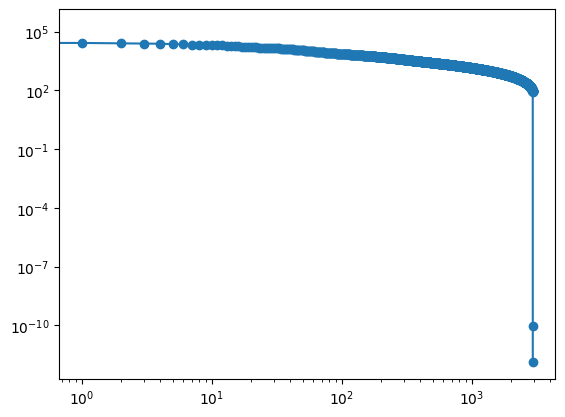

In [340]:
# plt.loglog(s, marker='o')

In [341]:
r = 10 #i will choose the first 10 singular values

# U.shape, s.shape, V.shape

((3900, 2933), (2933,), (2933, 2933))

In [342]:
#i will try to encode each audio as a projection on the first r singular vectors


      
# encoded_matrix = U.T @  matrix

In [343]:
# encoded_matrix.shape

(2933, 2933)

In [344]:
#prendo i primi 100 e ci faccio il modello di regressione
# X = encoded_matrix[:65].T
# X.shape




(2933, 65)

In [345]:
# y.shape


(2933,)

In [346]:
# dataset['silence_duration'] 

0       23.846893
1       19.388662
2       21.640998
3       19.644127
4       18.041905
          ...    
2928    17.461406
2929     1.509206
2930     1.645034
2931    16.346848
2932     2.275556
Name: silence_duration, Length: 2933, dtype: float64

In [347]:
# dataset

,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,hnr,num_pauses,...,60,61,62,63,64,65,66,67,68,69
0,1821.69060,3999.7170,145.43066,0.013795,0.082725,0.002254,0.210093,3112.257251,-123.999726,39,...,39.370149,199.651159,-167.533857,-165.864930,217.419280,27.054113,-228.811409,-39.867484,100.113153,52.196226
1,1297.81870,3998.8590,145.37268,0.025349,0.096242,0.007819,0.078849,1688.016389,-86.928478,21,...,136.838975,104.997729,76.204427,113.927096,-10.615399,119.594329,-67.893463,55.848209,-27.851359,317.647588
2,1332.85240,3998.8025,145.42395,0.019067,0.119456,0.002974,0.105365,2576.901706,-98.450670,1,...,127.505187,-35.180220,-19.388776,-100.936200,-11.948822,-60.909125,-27.168192,57.487230,-34.157133,150.192327
3,1430.34990,3998.4510,147.98083,0.017004,0.102389,0.022371,0.173701,3269.751413,-56.459762,9,...,-88.840146,-12.375672,-34.363769,141.163704,295.616422,-140.056843,173.956854,-159.030907,10.848650,-71.121623
4,1688.72340,3998.6113,145.44772,0.028027,0.124831,0.005369,0.107279,1930.897375,-80.349204,11,...,186.591230,15.337393,-86.000229,53.706159,117.108918,-88.384422,-92.369076,144.566565,-88.017969,-267.361325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2928,1641.14930,3999.1616,145.39359,0.023647,0.115361,0.001879,0.111799,2188.853478,-100.921055,11,...,-76.731396,-47.539219,104.986167,6.191839,-167.949556,-9.668420,-280.910936,169.530993,-150.708049,-36.389929
2929,1089.60050,3984.6550,145.58409,0.015317,0.126740,0.000339,0.070508,2712.362323,6.757283,1,...,-53.224863,153.845464,-33.994943,0.155324,129.762271,67.736053,27.563682,78.005795,-61.081621,29.766110
2930,994.46484,3989.1785,148.97475,0.009677,0.103535,0.001464,0.058442,2248.698477,-53.913449,1,...,126.639865,-243.909791,80.916472,169.712296,64.620437,118.825363,-10.928521,86.565002,118.345893,43.017122
2931,1600.00820,3999.7559,145.36101,0.019571,0.100946,0.004451,0.115139,1834.596924,-96.143090,19,...,-73.352603,134.644647,17.395473,-61.177116,80.169760,-135.335204,-158.501072,256.420817,-82.645573,-23.865495


In [375]:
# x = pd.DataFrame(dataset[['silence_duration','spectral_centroid_mean','jitter', 'num_pauses','hnr']])
# x = pd.concat([x, pd.DataFrame(X)], axis=1)
# X = x.values


In [349]:
# def try_model(X,y):
#     x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#     clf = RandomForestRegressor(n_estimators=200, random_state=42)
#     clf.fit(x_train, y_train)
#     ypred = clf.predict(x_test)
#     print(root_mean_squared_error(y_test, ypred))
#     return clf
    

In [ ]:
# functions.try_model(X,y)

NameError: name 'try_model' is not defined

In [350]:
# audios_vals = audios.values()



In [353]:
# from sklearn.preprocessing import StandardScaler
# curtosis = []
# mfccs = []
# entropy = []
# for key in audios.keys(): 
#     audio_val = audios[key]
#     # nomalized_audio = StandardScaler().fit_transform(audio_val)
#     # mfccs.append(librosa.feature.mfccs())
#     curtosis.append((sci.stats.kurtosis(audio_val).mean())) 
#     entropy.append((sci.stats.entropy(audio_val).mean()))
    

In [354]:
# curtosis[1].shape
# entropy[1]

np.float32(-inf)

In [355]:
# dataset

,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,hnr,num_pauses,...,60,61,62,63,64,65,66,67,68,69
0,1821.69060,3999.7170,145.43066,0.013795,0.082725,0.002254,0.210093,3112.257251,-123.999726,39,...,39.370149,199.651159,-167.533857,-165.864930,217.419280,27.054113,-228.811409,-39.867484,100.113153,52.196226
1,1297.81870,3998.8590,145.37268,0.025349,0.096242,0.007819,0.078849,1688.016389,-86.928478,21,...,136.838975,104.997729,76.204427,113.927096,-10.615399,119.594329,-67.893463,55.848209,-27.851359,317.647588
2,1332.85240,3998.8025,145.42395,0.019067,0.119456,0.002974,0.105365,2576.901706,-98.450670,1,...,127.505187,-35.180220,-19.388776,-100.936200,-11.948822,-60.909125,-27.168192,57.487230,-34.157133,150.192327
3,1430.34990,3998.4510,147.98083,0.017004,0.102389,0.022371,0.173701,3269.751413,-56.459762,9,...,-88.840146,-12.375672,-34.363769,141.163704,295.616422,-140.056843,173.956854,-159.030907,10.848650,-71.121623
4,1688.72340,3998.6113,145.44772,0.028027,0.124831,0.005369,0.107279,1930.897375,-80.349204,11,...,186.591230,15.337393,-86.000229,53.706159,117.108918,-88.384422,-92.369076,144.566565,-88.017969,-267.361325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2928,1641.14930,3999.1616,145.39359,0.023647,0.115361,0.001879,0.111799,2188.853478,-100.921055,11,...,-76.731396,-47.539219,104.986167,6.191839,-167.949556,-9.668420,-280.910936,169.530993,-150.708049,-36.389929
2929,1089.60050,3984.6550,145.58409,0.015317,0.126740,0.000339,0.070508,2712.362323,6.757283,1,...,-53.224863,153.845464,-33.994943,0.155324,129.762271,67.736053,27.563682,78.005795,-61.081621,29.766110
2930,994.46484,3989.1785,148.97475,0.009677,0.103535,0.001464,0.058442,2248.698477,-53.913449,1,...,126.639865,-243.909791,80.916472,169.712296,64.620437,118.825363,-10.928521,86.565002,118.345893,43.017122
2931,1600.00820,3999.7559,145.36101,0.019571,0.100946,0.004451,0.115139,1834.596924,-96.143090,19,...,-73.352603,134.644647,17.395473,-61.177116,80.169760,-135.335204,-158.501072,256.420817,-82.645573,-23.865495


In [356]:
# clone_dataset = dataset.copy()


In [373]:
# dataset = clone_dataset.copy()

In [365]:
# dataset['curtosis'] = curtosis
# dataset['entropy'] = entropy
# dataset.drop(columns=['entropy'], inplace=True)
# red_matrix = encoded_matrix[:70].T
# print(red_matrix.shape)
# dataset = pd.concat( [dataset, pd.DataFrame(red_matrix)], axis=1)
# dataset.columns = dataset.columns.astype(str)





(2933, 70)


In [367]:
# y.shape

(2933,)

In [374]:
# dataset

,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,hnr,num_pauses,...,60,61,62,63,64,65,66,67,68,69
0,1821.69060,3999.7170,145.43066,0.013795,0.082725,0.002254,0.210093,3112.257251,-123.999726,39,...,39.370149,199.651159,-167.533857,-165.864930,217.419280,27.054113,-228.811409,-39.867484,100.113153,52.196226
1,1297.81870,3998.8590,145.37268,0.025349,0.096242,0.007819,0.078849,1688.016389,-86.928478,21,...,136.838975,104.997729,76.204427,113.927096,-10.615399,119.594329,-67.893463,55.848209,-27.851359,317.647588
2,1332.85240,3998.8025,145.42395,0.019067,0.119456,0.002974,0.105365,2576.901706,-98.450670,1,...,127.505187,-35.180220,-19.388776,-100.936200,-11.948822,-60.909125,-27.168192,57.487230,-34.157133,150.192327
3,1430.34990,3998.4510,147.98083,0.017004,0.102389,0.022371,0.173701,3269.751413,-56.459762,9,...,-88.840146,-12.375672,-34.363769,141.163704,295.616422,-140.056843,173.956854,-159.030907,10.848650,-71.121623
4,1688.72340,3998.6113,145.44772,0.028027,0.124831,0.005369,0.107279,1930.897375,-80.349204,11,...,186.591230,15.337393,-86.000229,53.706159,117.108918,-88.384422,-92.369076,144.566565,-88.017969,-267.361325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2928,1641.14930,3999.1616,145.39359,0.023647,0.115361,0.001879,0.111799,2188.853478,-100.921055,11,...,-76.731396,-47.539219,104.986167,6.191839,-167.949556,-9.668420,-280.910936,169.530993,-150.708049,-36.389929
2929,1089.60050,3984.6550,145.58409,0.015317,0.126740,0.000339,0.070508,2712.362323,6.757283,1,...,-53.224863,153.845464,-33.994943,0.155324,129.762271,67.736053,27.563682,78.005795,-61.081621,29.766110
2930,994.46484,3989.1785,148.97475,0.009677,0.103535,0.001464,0.058442,2248.698477,-53.913449,1,...,126.639865,-243.909791,80.916472,169.712296,64.620437,118.825363,-10.928521,86.565002,118.345893,43.017122
2931,1600.00820,3999.7559,145.36101,0.019571,0.100946,0.004451,0.115139,1834.596924,-96.143090,19,...,-73.352603,134.644647,17.395473,-61.177116,80.169760,-135.335204,-158.501072,256.420817,-82.645573,-23.865495


In [369]:
# dataset.shape

(2933, 153)

In [370]:
# clf = try_model(dataset, y)

10.095436894578613


In [371]:
# def print_feature_importance(clf, dataset):
#     importances = clf.feature_importances_
#     feature_names = dataset.columns

#     # Create a DataFrame for better visualization
#     feature_importances = pd.DataFrame({'feature': feature_names, 'importance': importances})
#     feature_importances = feature_importances.sort_values(by='importance', ascending=False)
#     print(feature_importances.to_string())


In [372]:
# print_feature_importance(clf, dataset)

                    feature  importance
10         silence_duration    0.225578
12                 curtosis    0.035808
11                  english    0.024427
83                        0    0.016197
7    spectral_centroid_mean    0.011632
3                    jitter    0.011142
53                       40    0.010834
8                       hnr    0.010585
25                       12    0.010520
151                      68    0.009822
24                       11    0.009510
9                num_pauses    0.009374
13                        0    0.008551
108                      25    0.008174
26                       13    0.007742
62                       49    0.007713
148                      65    0.007552
57                       44    0.007351
20                        7    0.007159
80                       67    0.006840
63                       50    0.006804
54                       41    0.006377
14                        1    0.006292
52                       39    0.006289
